In [ ]:
#from Generate import Generate
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib

from matplotlib import gridspec
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams.update({'font.size': 14})
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
params = {'xtick.top': True, 'ytick.right': True, 'xtick.direction': 'in', 'ytick.direction': 'in'}
plt.rcParams.update(params)

import sys
import csv
from tqdm import tqdm
from matplotlib.legend_handler import HandlerTuple


from src.axionemulator import axionemulator

model = axionemulator(version=2)

Lightning automatically upgraded your loaded checkpoint from v1.5.10 to v2.6.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint emulators/lightning_logs/version_2/checkpoints/epoch=133-step=98623.ckpt`


'\nsys.path.append("/mn/stornext/d8/data/hansw/Dennis/axionemu_test/")\nfrom _predict import Predictor\n\nclass cm_emulator_class:\n    def __init__(self, version=0):\n        self.predictor = Predictor.from_path(f"/mn/stornext/d8/data/hansw/Dennis/axionemu_test/emulators/lightning_logs/version_{version}")\n\n    def __call__(\n        self,\n        params,\n        return_tensors: bool = False,\n    ):\n        inputs = np.array(params)\n        return self.predictor(inputs).reshape(-1)\n\n_emulator = cm_emulator_class(version=2,)\n'

In [11]:
out = "output_HM"
Omega_b = 0.049
Omega_cdm = 0.2637
A_s = 2.1e-9
n_s = 0.966
OmegaMnu = 0.0
h = 0.6766
redshift = 0.0
#k = np.logspace(-3, 0.78, 256)

path_camb = "/mn/stornext/d8/data/hansw/Dennis/pipeline/output_HM/"
path_axionHM = "/mn/stornext/d8/data/dennisfr/local/axionHMcode/"
path_HM      = "/mn/stornext/d8/data/dennisfr/local/HMcode/data/"

data_camb_LCDM = np.loadtxt(path_camb+"axioncamb_1e-23_0.300_LCDM_matterpower_z0.0.dat")
data_axionHM_LCDM = np.loadtxt(path_axionHM+"LCDM.txt")
data_HM_LCDM = np.loadtxt(path_HM+"HM_LCDM.dat")


params = lambda m, f : [[Omega_cdm, np.log10(A_s), np.log10(f), np.log10(m), redshift, np.log10(ki)] for ki in k]

1e-27_0.300
1e-27_0.600
1e-27_0.900
1e-25_0.300
1e-25_0.600
1e-25_0.900
1e-23_0.300
1e-23_0.600
1e-23_0.900


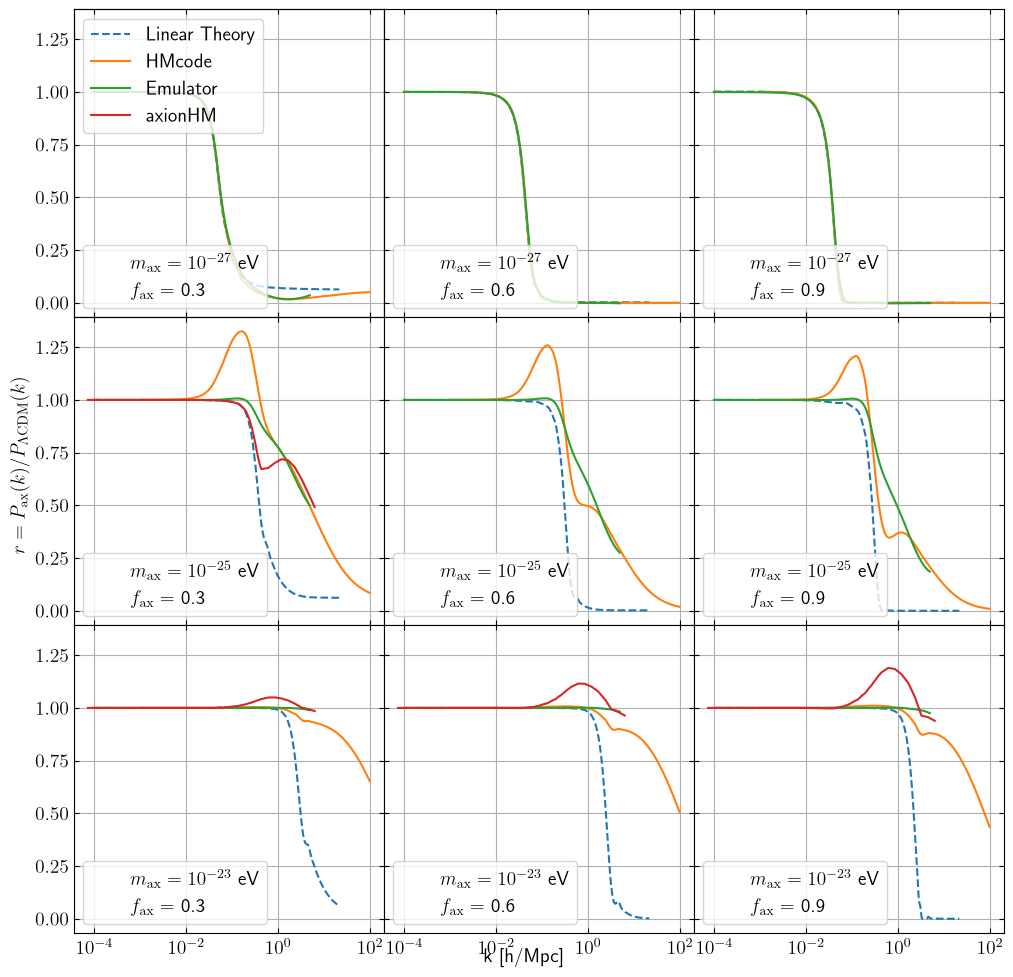

In [12]:
#f = [0.001, 0.05, 0.1]
f = [0.3, 0.6, 0.9]
m = [1e-27, 1e-25, 1e-23]

# ['OmegaCDM', 'logA_s', 'f_ax', 'logm_ax', 'z', 'k',]
fig, ax = plt.subplots(figsize=(12,12), sharex=True, sharey=True,ncols=3, nrows=3)

plot = True

for i, mi in enumerate(m):
    for j, fj in enumerate(f):
        label="%.e_%.3f"%(mi,fj)
        print(label)

        data_camb = np.loadtxt(path_camb+"axioncamb_"+label+"_matterpower_z0.0.dat")
        data_camb_LCDM = np.loadtxt(path_camb+"axioncamb_"+label+"_LCDM_matterpower_z0.0.dat")
        try:
            plot = True
            data_axionHM = np.loadtxt(path_axionHM+"axion_"+label+".txt")
        except:
            plot = False
            pass
        data_HM = np.loadtxt(path_HM+"HM_"+label+".dat")

        #k = data_axionHM[:,0]
        k = np.logspace(np.log10(data_camb[0,0]), np.log10(5), 126)
        k = np.logspace(-4, np.log10(5), 126)

        if i == 0 and j == 0:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--", label="Linear Theory")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16], label="HMcode")
        else: 
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16])

        p = params(mi, fj)
        if i == 0 and j == 0:
            ax[i,j].plot(k, model(p), label="Emulator")
        else: 
            ax[i,j].plot(k, model(p)) 

        
        if plot:
            if i == 0 and j == 0:
                ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2], label="axionHM")
            else:
                ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2])
        else:
            if i == 0 and j == 0:
                ax[i,j].plot([], [], label="axionHM")

        #else:
        #    ax[i,j].plot([], [], label="axionHM")
    
        mantissa, exponent = f"{mi:.1e}".split("e")
        exponent = int(exponent)

        #ax[i,j].set_title(r"$m_{\rm ax} = 10^{%d}$ eV, $f_{\rm ax} =$ %.1f"%(exponent, fj))
        if i == 0 and j == 0:
            ax2 = ax[i,j].twinx()
            ax2.plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax2.plot([], [], label=r"$f_{\rm ax} =$ %.1f"%(fj), ls='None')
            legend = ax2.legend(loc=3, handletextpad=0)
            ax2.get_yaxis().set_visible(False)
            ax[i,j].legend(loc=2)
        else:
            ax[i,j].plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax[i,j].plot([], [], label=r"$f_{\rm ax} =$ %.1f"%(fj), ls='None')

            legend = ax[i,j].legend(loc=3, handler_map={tuple: HandlerTuple(ndivide=None)}, handletextpad=0)

        for handle in legend.legend_handles:
            handle.set_visible(False)

        ax[i,j].grid()
        ax[i,j].set_xscale("log")
        #ax[i,j].set_yscale("log")

        #ax[i,j].legend()
#ax[0,0].legend()

#ax = fig.add_axes([0,0,1,1])

#ax.set_xlabel("k [h/Mpc]")
#fig.supylabel(r"P(k) [(Mpc/h)$^3$]")
fig.text(0.5, 0.09, 'k [h/Mpc]', va='center', ha='center')
fig.text(0.08, 0.5, r"$r = P_{\rm ax}(k)/P_{\Lambda \rm CDM}(k)$", va='center', ha='center', rotation='vertical')

plt.subplots_adjust(hspace=0.0, wspace=0.0)
#plt.savefig("figures/comparison_high_f_ax.pdf", bbox_inches="tight")
plt.show()

1e-27_0.001
1e-27_0.050
1e-27_0.100
1e-25_0.001
1e-25_0.050
1e-25_0.100
1e-23_0.001
1e-23_0.050
1e-23_0.100


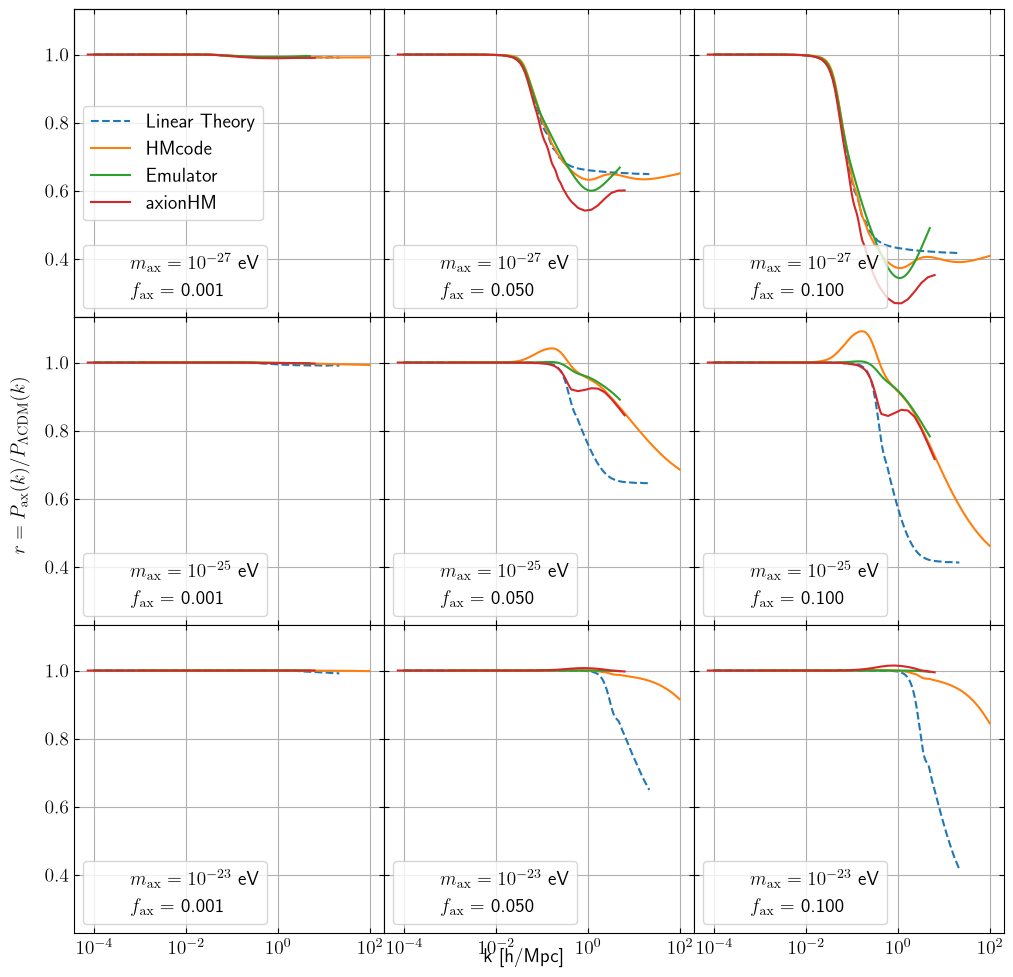

In [13]:
f = [0.001, 0.05, 0.1]
m = [1e-27, 1e-25, 1e-23]

fig, ax = plt.subplots(figsize=(12,12), sharex=True, sharey=True,ncols=3, nrows=3)

for i, mi in enumerate(m):
    for j, fj in enumerate(f):
        label="%.e_%.3f"%(mi,fj)
        print(label)

        data_camb = np.loadtxt(path_camb+"axioncamb_"+label+"_matterpower_z0.0.dat")
        data_camb_LCDM = np.loadtxt(path_camb+"axioncamb_"+label+"_LCDM_matterpower_z0.0.dat")
        data_axionHM = np.loadtxt(path_axionHM+"axion_"+label+".txt")
        data_HM = np.loadtxt(path_HM+"HM_"+label+".dat")

        #k = data_axionHM[:,0]
        #k = np.logspace(np.log10(data_camb[0,0]), np.log10(5), 126)
        k = np.logspace(-4, np.log10(5), 126)
        
        if i == 0 and j == 0:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--", label="Linear Theory")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16], label="HMcode")
        else:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16])

        p = params(mi, fj)

        if i == 0 and j == 0:
            ax[i,j].plot(k, model(p), label="Emulator")
            ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2], label="axionHM")

        else: 
            ax[i,j].plot(k, model(p))
            ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2])

        ax[i,j].grid()
        ax[i,j].set_xscale("log")
        #ax[i,j].set_yscale("log")

        mantissa, exponent = f"{mi:.1e}".split("e")
        exponent = int(exponent)

        if i == 0 and j == 0:
            ax2 = ax[i,j].twinx()
            ax2.plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax2.plot([], [], label=r"$f_{\rm ax} =$ %.3f"%(fj), ls='None')
            legend = ax2.legend(loc=3, handletextpad=0)
            ax2.get_yaxis().set_visible(False)
            ax[i,j].legend(loc="center left")
        else:
            ax[i,j].plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax[i,j].plot([], [], label=r"$f_{\rm ax} =$ %.3f"%(fj), ls='None')

            legend = ax[i,j].legend(loc=3, handler_map={tuple: HandlerTuple(ndivide=None)}, handletextpad=0)

        for handle in legend.legend_handles:
            handle.set_visible(False)

fig.text(0.5, 0.09, 'k [h/Mpc]', va='center', ha='center')
fig.text(0.08, 0.5, r"$r = P_{\rm ax}(k)/P_{\Lambda \rm CDM}(k)$", va='center', ha='center', rotation='vertical')

plt.subplots_adjust(hspace=0.0, wspace=0.0)
#plt.savefig("figures/comparison_low_f_ax.pdf", bbox_inches="tight")
plt.show()